명목형 0,1 만 있을떄, 혼동행렬

총 12명 중 6명이 범인
모두다 범인이라고 생각
처음에는 다 negative 로 분류
> 즉 FPR 이 0 으로 시작
>
> 분류기준을 조금 완화,

오른쪾으로 가면 틀린ㄱ, 위로가면 맞춘거~!



# [LAB 09] 지도학습 > 분류 > 02-로지스틱 | 성능평가
## #01.준비 작업
### [1] 패키지 가져오긴

In [16]:
from hossam import *

import pandas as pd
from pandas import merge
from pandas import Series, DataFrame,concat
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from itertools import product
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

#로지스틱 회귀 모형
from sklearn.linear_model import LogisticRegression

#로지스틱 성능 평가 함수
from sklearn.metrics import (
      log_loss,
      accuracy_score,
      confusion_matrix,
      roc_auc_score,
      roc_curve,accuracy_score,
      recall_score,
      precision_score,
      f1_score)



### [2] 앞서 정의한 함수
- hs_describe
- hs_category_describe

### [3] 데이터 가져오기

In [17]:
origin = load_data('pima_indians_diabetes')
origin.head()

이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


## #02. 데이터 품질 확인
### [1] 명목형 타입 변환

In [18]:
df1=origin.astype({'Outcome':'category'})
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 49.0 KB


### [2] 연속형 데이터의 품질 확인

In [19]:
import numpy as np
from pandas import DataFrame, concat

def hs_describe(data, columns=None):
    num_columns = list(data.select_dtypes(include=np.number).columns)

    if not columns:
        columns = num_columns

    # 기술통계량 구하기
    desc = data[columns].describe().T

    # 각 컬럼별 결측치 수 (na_count) 추가
    na_counts = data[columns].isnull().sum()
    desc.insert(1, 'na_count', na_counts)

    # 결측치 비율 (na_rate) 추가
    desc.insert(2, 'na_rate', (na_counts / len(data)) * 100)

    # 추가 통계량 계산
    additional_stats = []

    for f in columns:
        # 숫자 타입이 아니라면 건너뜀
        if f not in num_columns:
            continue

        # 사분위수
        q1 = data[f].quantile(q=0.25)
        q3 = data[f].quantile(q=0.75)

        # 이상치 경계 (Tukey's fences)
        iqr = q3 - q1
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # 왜도
        skew = data[f].skew()

        # 이상치 개수 및 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # 분포 특성 판정 (왜도 기준)
        abs_skew = abs(skew)
        if abs_skew < 0.5:
            dist = "거의 대칭"
        elif abs_skew < 1.0:
            if skew > 0:
                dist = "약한 우측 꼬리"
            else:
                dist = "약한 좌측 꼬리"
        elif abs_skew < 2.0:
            if skew > 0:
                dist = "중간 우측 꼬리"
            else:
                dist = "중간 좌측 꼬리"
        else:
            if skew > 0:
                dist = "극단 우측 꼬리"
            else:
                dist = "극단 좌측 꼬리"

        # 로그변환 필요성 판정
        if abs_skew < 0.5:
            log_need = "낮음"
        elif abs_skew < 1.0:
            log_need = "중간"
        else:
            log_need = "높음"

        additional_stats.append({
            'field': f,
            'iqr': iqr,
            'up': up,
            'down': down,
            'outlier_count': outlier_count,
            'outlier_rate': outlier_rate,
            'skew': skew,
            'dist': dist,
            'log_need': log_need
        })

    additional_df = DataFrame(additional_stats).set_index('field')

    # 결과 병합
    result = concat([desc, additional_df], axis=1)

    return result


In [20]:
hs_describe(df1)

,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,up,down,outlier_count,outlier_rate,skew,dist,log_need
Pregnancies,768.000,0,0.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,5.000,13.500,-6.500,4,0.521,0.902,약한 우측 꼬리,중간
Glucose,768.000,0,0.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000,41.250,202.125,37.125,5,0.651,0.174,거의 대칭,낮음
BloodPressure,768.000,0,0.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000,18.000,107.000,35.000,45,5.859,-1.844,중간 좌측 꼬리,높음
SkinThickness,768.000,0,0.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000,32.000,80.000,-48.000,1,0.130,0.109,거의 대칭,낮음
Insulin,768.000,0,0.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000,127.250,318.125,-190.875,34,4.427,2.272,극단 우측 꼬리,높음
BMI,768.000,0,0.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100,9.300,50.550,13.350,19,2.474,-0.429,거의 대칭,낮음
DiabetesPedigreeFunction,768.000,0,0.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,0.382,1.200,-0.330,29,3.776,1.920,중간 우측 꼬리,높음
Age,768.000,0,0.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,17.000,66.500,-1.500,9,1.172,1.130,중간 우측 꼬리,높음


## ✏️ 인사이트

### ✅ 결측값 처리 (우선순위: 높음)
- 문제: **0의 결측값은 없으나, 0값이 다수 존재 (생리학적으로 불가능한 값)**

- 영향 변수:
  - **Glucose** : 최소값 0 → 혈당이 0일 수 없음
  - **BloodPressure** : 최소값 0 → 혈압이 0일 수 없음
  - **BMI** : 최소값 0 → BMI가 0일 수 없음
  - **SkinThickness** : Q1이 0 → 다수의 0값 존재
  - **Insulin** : Q1이 0 → 다수의 0값 존재

- 처리 방법:
  - **0값을 NaN으로 변환 후 처리**
  - **중앙값/평균값 대체 또는 KNN Imputer 활용**
  - **삭제할 경우 데이터 손실 고려 필요**

---

### ✅ 이상치 처리 - 왜도 조정 및 변환 (우선순위: 중간)
- 로그변환 필요성 **높음**:
  - **BloodPressure** : 중간 좌측 꼬리 (skew: -1.844)
  - **Insulin** : 극단 우측 꼬리 (skew: 2.272)
  - **DiabetesPedigreeFunction** : 중간 우측 꼬리 (skew: 1.920)
  - **Age** : 중간 우측 꼬리 (skew: 1.130)

- 처리 방법:
  - **로그변환**

---

### ✅ 정규화/표준화 (우선순위: 낮음)
- 필요성: 변수별 스케일 차이 존재  
  (예: **Age: 21~81**, **Insulin: 0~846**)

- 처리 방법:
  - **StandardScaler 또는 MinMaxScaler 적용**
  - **로지스틱 회귀의 경우 StandardScaler 권장**


### [3] 명목형 데이터의 품질 확인

In [21]:

def hs_category_describe(data, columns=None):
    num_columns = data.select_dtypes(include=np.number).columns

    if not columns:
        # 명목형(범주형) 컬럼 선택: object, category, bool 타입
        columns = data.select_dtypes(
            include=['object', 'category', 'bool']
        ).columns  # type: ignore

    result = []
    summary = []

    for f in columns:
        # 숫자형 컬럼은 건너뜀
        if f in num_columns:
            continue

        # 각 범주값의 빈도수 계산 (NaN 포함)
        value_counts = data[f].value_counts(dropna=False)

        # 범주별 빈도/비율 정보 추가 (category_table 기능)
        for category, count in value_counts.items():
            rate = (count / len(data)) * 100
            result.append({
                "변수": f,
                "범주": category,
                "빈도": count,
                "비율(%)": round(rate, 2)
            })

        if len(value_counts) == 0:
            continue

        # 최대/최소 범주 정보 추가 (category_describe 기능)
        max_category = value_counts.index[0]
        max_count = value_counts.iloc[0]
        max_rate = (max_count / len(data)) * 100

        min_category = value_counts.index[-1]
        min_count = value_counts.iloc[-1]
        min_rate = (min_count / len(data)) * 100

        summary.append({
            "변수": f,
            "최대_범주": max_category,
            "최대_비율(%)": round(max_rate, 2),
            "최소_범주": min_category,
            "최소_비율(%)": round(min_rate, 2)
        })

    return DataFrame(result), DataFrame(summary).set_index("변수")


In [22]:
a,b = hs_category_describe(df1)
display(a)
display(b)

,변수,범주,빈도,비율(%)
0,Outcome,0,500,65.100
1,Outcome,1,268,34.900


,최대_범주,최대_비율(%),최소_범주,최소_비율(%)
변수,,,,
Outcome,0,65.100,1,34.900


- 변수 차지 비율 차이가 크지만 테스트 데이터이므로 진행

## #03.데이터 전처리
### [1] 결측치 정제

In [23]:
# 0값을 결측치로 처리할 피처명 리스트
zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df2 = df1.copy()


df2[zero_features] = df2[zero_features].replace(0, np.nan)
df2.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.000,72.000,35.000,NaN,33.600,0.627,50,1
1,1,85.000,66.000,29.000,NaN,26.600,0.351,31,0
2,8,183.000,64.000,NaN,NaN,23.300,0.672,32,1
3,1,89.000,66.000,23.000,94.000,28.100,0.167,21,0
4,0,137.000,40.000,35.000,168.000,43.100,2.288,33,1


In [24]:
imr = SimpleImputer(missing_values=np.nan, strategy='median')
df_imr = imr.fit_transform(df2.values)

df3 = DataFrame(
    df_imr,
    index=df2.index,      # 원본의 인덱스
    columns=df2.columns   # 원본의 컬럼명
)

# 결측치 처리 과정에서 범주형 데이터 타입이 변경되었으므로 복원
df3 = df3.astype({"Outcome": "category"})

# 데이터 품질 재검사
desc = hs_describe(df3)
desc


,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,up,down,outlier_count,outlier_rate,skew,dist,log_need
Pregnancies,768.000,0,0.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,5.000,13.500,-6.500,4,0.521,0.902,약한 우측 꼬리,중간
Glucose,768.000,0,0.000,121.656,30.438,44.000,99.750,117.000,140.250,199.000,40.500,201.000,39.000,0,0.000,0.536,약한 우측 꼬리,중간
BloodPressure,768.000,0,0.000,72.387,12.097,24.000,64.000,72.000,80.000,122.000,16.000,104.000,40.000,14,1.823,0.142,거의 대칭,낮음
SkinThickness,768.000,0,0.000,29.108,8.791,7.000,25.000,29.000,32.000,99.000,7.000,42.500,14.500,87,11.328,0.838,약한 우측 꼬리,중간
Insulin,768.000,0,0.000,140.672,86.383,14.000,121.500,125.000,127.250,846.000,5.750,135.875,112.875,346,45.052,3.380,극단 우측 꼬리,높음
BMI,768.000,0,0.000,32.455,6.875,18.200,27.500,32.300,36.600,67.100,9.100,50.250,13.850,8,1.042,0.599,약한 우측 꼬리,중간
DiabetesPedigreeFunction,768.000,0,0.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,0.382,1.200,-0.330,29,3.776,1.920,중간 우측 꼬리,높음
Age,768.000,0,0.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,17.000,66.500,-1.500,9,1.172,1.130,중간 우측 꼬리,높음


### [2] 이상치 처리 (로그변환)

In [25]:
log_fields = desc[desc['log_need'] != '낮음'].index.tolist()

df4 = df3.copy()

for f in log_fields:
    df4[f] = np.log1p(df4[f])  # log(1 + x) 변환 적용

hs_describe(df4)


,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,up,down,outlier_count,outlier_rate,skew,dist,log_need
Pregnancies,768.000,0,0.000,1.311,0.770,0.000,0.693,1.386,1.946,2.890,1.253,3.825,-1.186,0,0.000,-0.243,거의 대칭,낮음
Glucose,768.000,0,0.000,4.779,0.248,3.807,4.613,4.771,4.951,5.298,0.338,5.457,4.106,4,0.521,-0.058,거의 대칭,낮음
BloodPressure,768.000,0,0.000,72.387,12.097,24.000,64.000,72.000,80.000,122.000,16.000,104.000,40.000,14,1.823,0.142,거의 대칭,낮음
SkinThickness,768.000,0,0.000,3.359,0.314,2.079,3.258,3.401,3.497,4.605,0.238,3.854,2.900,96,12.500,-0.859,약한 좌측 꼬리,중간
Insulin,768.000,0,0.000,4.827,0.495,2.708,4.808,4.836,4.854,6.742,0.046,4.923,4.739,346,45.052,-0.175,거의 대칭,낮음
BMI,768.000,0,0.000,3.489,0.204,2.955,3.350,3.506,3.627,4.221,0.277,4.043,2.934,3,0.391,-0.038,거의 대칭,낮음
DiabetesPedigreeFunction,768.000,0,0.000,0.365,0.199,0.075,0.218,0.317,0.486,1.230,0.268,0.888,-0.184,13,1.693,1.118,중간 우측 꼬리,높음
Age,768.000,0,0.000,3.482,0.313,3.091,3.219,3.401,3.738,4.407,0.519,4.516,2.441,0,0.000,0.615,약한 우측 꼬리,중간


### [3] 훈련,검증 데이터 분리

In [26]:
df = df4

# 종속변수는 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')

yname = "Outcome"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((614, 8), (154, 8), (614,), (154,))

## #04. 로지스틱 모형 적합

In [27]:
%%time

pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs.fit(x_train, y_train)

estimator = gs.best_estimator_
estimator


CPU times: total: 172 ms
Wall time: 243 ms


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    random_state=52))])

## #05. 성능 평가 지표
### [1] 의사결정계수
- estimator.score 로 구한 값은 r2 가 아니라 정확도 값
- 다항로지스틱에서는 사용할 수 없음
- 기본 전제는 종속 변수가 0,1 로 두개인 경우

#### 로그 손실값

In [ ]:
#예측값 선계산

y_pred_proba=estimator.predict_proba(x_test)
y_pred_proba[:5]

array([[0.17157015, 0.82842985],
       [0.95274504, 0.04725496],
       [0.41211228, 0.58788772],
       [0.35137747, 0.64862253],
       [0.98235443, 0.01764557]])

In [29]:
log_loss_test = -log_loss(y_test,y_pred_proba,normalize=False)
log_loss_test

-77.18386940419566

#### 로그 손실 계산

In [30]:
y_null = np.ones_like(y_test)*y_test.mean()
log_loss_null = -log_loss(y_test,y_null,normalize=False)
log_loss_null

-99.76854365841893

#### 의사결정계수
#### 보정된 r2 값
- 보정된 r2 갑을 구하기 위해 로그 손실값 계산

In [31]:
pseudo_r2 = 1-(log_loss_test/log_loss_null)
pseudo_r2

0.22637069186403302

In [32]:
r2=estimator.score(x_test,y_test)
r2

0.7662337662337663

### [2] 예측값
#### 위/양성 확률
- 0으로 분류될 확률과 1로 분류될 확률을 의미

In [33]:
y_pred_proba=estimator.predict_proba(x_test)
y_pred_proba[:5]

array([[0.17157015, 0.82842985],
       [0.95274504, 0.04725496],
       [0.41211228, 0.58788772],
       [0.35137747, 0.64862253],
       [0.98235443, 0.01764557]])

#### 보통은 1로 분류될 확률만 선택적으로 추출함
- roc-curve 산정에 사용

In [34]:
y_pred_proba_1 =estimator.predict_proba(x_test)[:,1]
y_pred_proba_1[:5]

array([0.82842985, 0.04725496, 0.58788772, 0.64862253, 0.01764557])

#### 예측 결과값
- 0,1 중에서 예측 결과를 의미

In [35]:
y_pred = estimator.predict(x_test)
y_pred

array([1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1])

### [3] 혼동행렬

In [36]:
cm = confusion_matrix(y_test, y_pred)

((TN,FP),(FN,TP)) = cm
print(TN,TP,FN,FP)


cmdf = DataFrame(
    cm,
    index=['Actual 0 (TN/FP)', 'Actual 1 (FN/TP)'],
    columns=['Predicted (Negative)', 'Predicted (Positive)']
)

cmdf


74 44 10 26


,Predicted (Negative),Predicted (Positive)
Actual 0 (TN/FP),74,26
Actual 1 (FN/TP),10,44


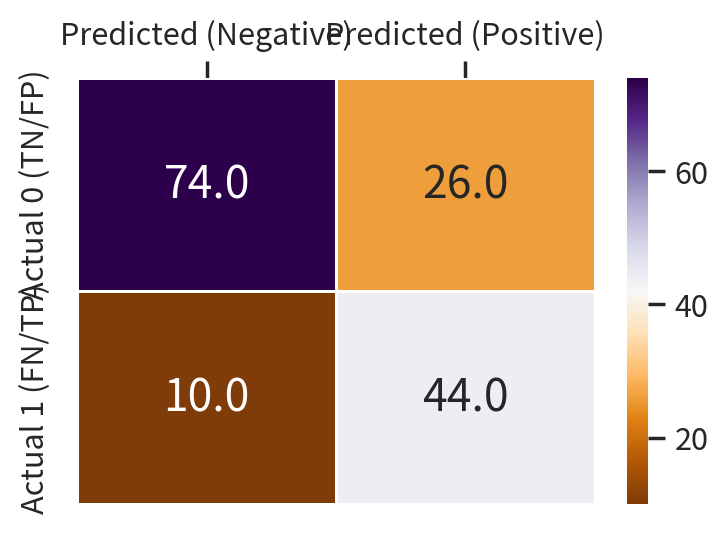

In [37]:
# 1) 그래프 초기화
width_px = 800          # 그래프 가로 크기
height_px = 600         # 그래프 세로 크기
rows = 1                # 그래프 행 수
cols = 1                # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=cmdf,
    annot=True,
    fmt="0.1f",
    linewidth=0.5,
    cmap="PuOr"
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()     # x축의 변수 이름을 상단으로 이동

# 4) 출력
plt.tight_layout()      # 여백 제거
plt.show()              # 그래프 화면 출력
plt.close()             # 그래프 작업 종료


### [5] 정확도 (Accuracy)

- 전체 데이터(FP + FN + TP + TN) 중에서  
  **올바르게 판정한 데이터(TP + TN)의 비율**

\[
\text{Accuracy}
= \frac{\text{정확히 예측한 데이터 건수}}{\text{전체 예측 데이터 건수}}
= \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
\]


In [38]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.7662337662337663

### [6] 정밀도 (Precision)
- **양성으로 예측한 데이터 중에서 실제로도 양성인 비율**

\[
\text{Precision}
= \frac{\text{예측과 실제 값이 Positive로 일치하는 것}}
       {\text{Positive로 예측한 것들}}
= \frac{\text{TP}}{\text{TP} + \text{FP}}
\]


- **실제 음성 데이터를 양성으로 잘못 판단(FP)하는 것이 더 큰 문제인 경우에 중요**
  - 예: **스팸 메일 분류 모델**

In [39]:
precision = precision_score(y_test, y_pred)
precision


0.6285714285714286

### [7] 재현율 (Recall ,TPR)

- **실제로 양성인 관측치 중에서 양성으로 예측한 비율**
- **TPR(True Positive Rate)** 또는 **민감도(Sensitivity)** 라고도 한다.

\[
\text{TPR (Recall)}
= \frac{\text{예측과 실제 값이 Positive로 일치하는 것}}
       {\text{실제 값이 Positive인 것들}}
= \frac{\text{TP}}{\text{TP} + \text{FN}}
\]

- **실제 양성 데이터를 음성으로 잘못 판단(FN)하는 것이 더 큰 문제인 경우에 중요**
  - 예: **암 판단 모델**

In [40]:
tpr = recall_score(y_test, y_pred)
tpr


0.8148148148148148

### [8] 위양성율,거짓 양성 비율(Fallout, FPR)

FPR(False Positive Rate)이라고도 한다.

\[
\text{FPR}
= \frac{\text{양성으로 예측한 데이터 건수 중 실제 값이 Negative인 것들}}
{\text{실제 값이 Negative인 것들}}
= \frac{\text{FP}}{\text{FP} + \text{TN}}
\]

- 다항로지스틱에서는 사용할 수 없음


In [41]:
fpr = FP/(TN+FP)
fpr

0.26

### [9] 특이성 (Specificity) TNR

1에서 위양성률의 값을 뺀 값으로 실제 값 Negative가 정확히 예측되어야 하는 수준을 의미한다.

TNR, True Negative Rate

\[
\text{TNR}
= 1 - \text{FPR}
= 1 - \frac{\text{FP}}{\text{FP} + \text{TN}}
\]

- 다항로지스틱에서는 사용할 수 없음



In [42]:
tnr = 1 - (FP / (TN + FP))
tnr


0.74

### [10] F1 Score

- **정밀도(Precision)와 재현율(Recall)을 결합한 지표**
- 두 지표 중 어느 한쪽으로도 치우치지 않을 때 상대적으로 높은 값을 가짐
- **조화 평균(Harmonic Mean)**을 사용하여 계산

\[
\text{F1}
= 2 \times \frac{\text{Precision} \times \text{Recall}}
         {\text{Precision} + \text{Recall}}
\]

- Precision 또는 Recall 중 하나라도 매우 낮으면  
  **F1-score 역시 낮아짐**
- 클래스 불균형 데이터에서 Accuracy보다 더 신뢰도 높은 경우가 많음

In [43]:
f1 = f1_score(y_test, y_pred)
f1


0.7096774193548387

### [11] ROC Curve
재현율(recall, FPR)을 X축으로, 위양성률(fall-out, TPR)을 Y축으로 잡은 그래프

FPR과 TPR 둘 다 양성을 많이 예측할수록 높아지기 때문에 비례한다.  
FPR 대비 TPR이 좋게 나오도록 해야 하는데, 즉  
FPR과 TPR로 그려본 그래프를 ROC curve라면 면적이 클수록 좋으며  
(FPR이 조금만 높아져도 TPR이 큰 폭으로 오름)  
이것을 시각적으로 확인하기 위해 ROC_curve를 이용한다.

- 다항로지스틱에서는 사용할 수 없음


### ✅ ROC Curve & AUC

- **ROC Curve**는  
  - x축: **FPR (False Positive Rate, 위양성률)**  
  - y축: **TPR (True Positive Rate, 재현율 / 민감도)**  
  로 구성된 그래프이다.

- 분류 임계값(threshold)을 변화시키면서  
  **FPR과 TPR의 관계를 시각화**한다.

- FPR과 TPR은 모두  
  → 양성으로 예측하는 비율이 커질수록 증가하는 경향이 있다.

- 좋은 모델일수록  
  - **FPR은 조금만 증가해도**
  - **TPR은 크게 증가**한다.
  → 즉, ROC 곡선이 **좌상단에 가까울수록 우수**

---

### ✅ AUC (Area Under the Curve)

- **ROC 곡선 아래 면적**
- 값의 범위: **0 ~ 1**
  - 0.5 : 랜덤 분류기
  - 1.0 : 완벽한 분류기
- **임계값에 독립적인 성능 지표**
- 클래스 불균형 상황에서도 비교적 안정적





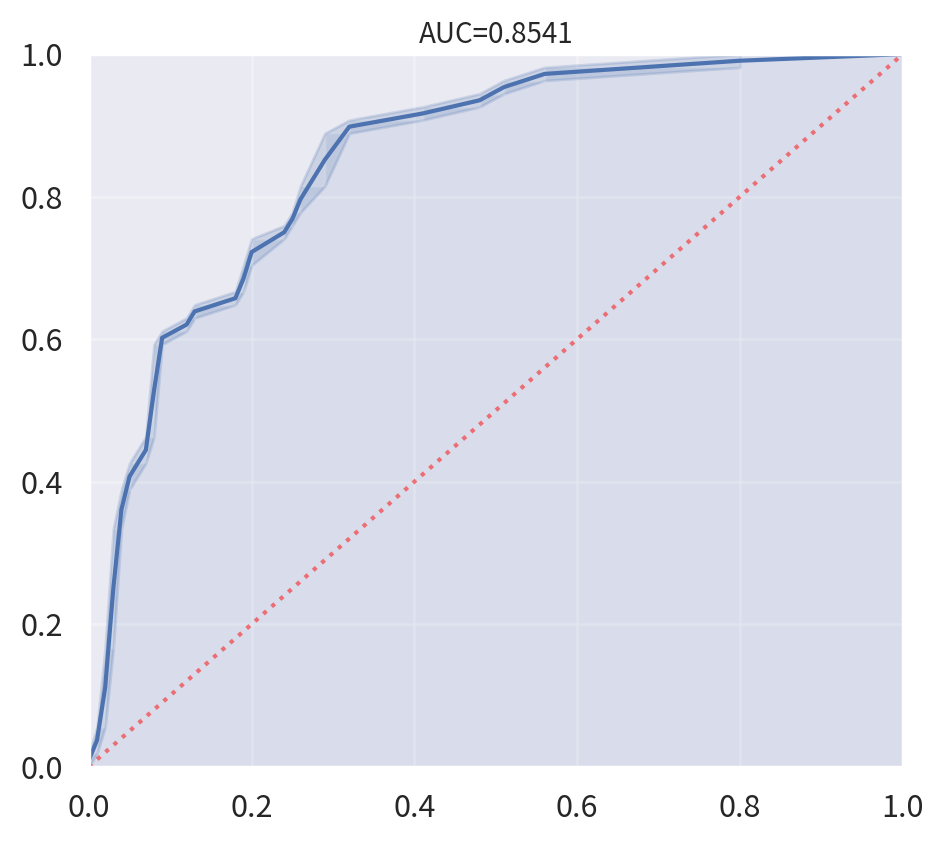

In [44]:
# AUC 계산
auc = roc_auc_score(y_test, y_pred_proba_1)

# ROC Curve 계산
roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

# 1) 그래프 초기화
width_px = 1000          # 그래프 가로 크기
height_px = 900          # 그래프 세로 크기
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) LinePlot 그리기
sb.lineplot(x=roc_fpr, y=roc_tpr)
sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)
ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


### [12] 결과표 구성하기

In [45]:
if hasattr(estimator, "named_steps"):
    classname = estimator.named_steps["model"].__class__.__name__
else:
    classname = estimator.__class__.__name__

score_df = DataFrame(
    {
        "의사결정계수(R2)": [pseudo_r2],
        "정확도(Accuracy)": [accuracy],
        "정밀도(Precision)": [precision],
        "재현율(Recall)": [tpr],
        "위양성율(Fallout)": [fpr],
        "특이성(TNR)": [tnr],
        "F1 Score": [f1],
        "AUC": [auc],
    },
    index=[classname]
)

score_df


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),재현율(Recall),위양성율(Fallout),특이성(TNR),F1 Score,AUC
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854


## #06 ROC Curve 해석 방법

True Positive Rate 와 False Positive Rate

Recall 은 True Positive Rate 의 다른 이름.

TPR 로 부르는 이유는 FPR 과 함께 쓸 경우 이해하기 훨씬 쉽기 때문.

TPR 은 Positive 예측이 성공한 비율을 설명하는 값으로 높을수록 좋음

FPR 은 Positive 예측이 실패한 비율을 설명하는 값으로 낮을수록 좋음

Threshold 가 100%에서부터 시작해 0%까지 도달하는 과정에서 그래프가 그려짐


## #07 과적합 판정
### [1] 과적합 판정 표 구성
#### 문제 유형 판별


- dir(estimator) 로 estimator 객체가 가진 기능 리스트 확인 가능

In [46]:
is_classification = (
    hasattr(estimator, "_estimator_type")
    and estimator._estimator_type == "classifier"
)

is_classification


True

#### 클래스 이름

In [47]:
if hasattr(estimator, "named_steps"):
    classname = estimator.named_steps["model"].__class__.__name__
else:
    classname = estimator.__class__.__name__

classname


'LogisticRegression'

#### 평가 기준, 교차 검증수, 학습 곡선 데이터 비율, jobs

In [48]:
scoring = "roc_auc"
cv = 5
train_sizes = np.linspace(0.1, 1.0, 10)
n_jobs = -1

scoring, cv, train_sizes


('roc_auc', 5, array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]))

#### learning curve 계산

In [49]:
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring=scoring,
    n_jobs=n_jobs,
    shuffle=False,
    random_state=52,
)

train_sizes, train_scores, cv_scores


(array([ 61, 122, 184, 245, 307, 368, 429, 491, 552, 614]),
 array([[0.93076923, 0.81699346, 0.81699346, 0.81699346, 0.81699346],
        [0.87694444, 0.85396825, 0.85396825, 0.85396825, 0.85396825],
        [0.82097342, 0.82133754, 0.84427083, 0.84427083, 0.84427083],
        [0.84375871, 0.84856506, 0.84238596, 0.84238596, 0.84238596],
        [0.83959833, 0.84755176, 0.82426019, 0.82068873, 0.82068873],
        [0.83768997, 0.84146537, 0.82086066, 0.82178898, 0.82178898],
        [0.84894099, 0.8508226 , 0.83470835, 0.83046655, 0.83163453],
        [0.85955514, 0.86203892, 0.84752549, 0.83255711, 0.82683101],
        [0.852362  , 0.8551314 , 0.84055563, 0.82948532, 0.83546649],
        [0.85432243, 0.85734813, 0.84440421, 0.83408521, 0.84886682]]),
 array([[0.75592593, 0.75814815, 0.8412963 , 0.82377358, 0.80358491],
        [0.75703704, 0.75777778, 0.83777778, 0.85660377, 0.82358491],
        [0.79185185, 0.78388889, 0.84037037, 0.88396226, 0.83301887],
        [0.80018519, 0.78592

#### 과적합 판정

In [50]:
# [NEW] 분류는 score를 그대로 사용
train_metric = -train_scores   # AUC
cv_metric = cv_scores          # Accuracy

train_mean = train_metric.mean(axis=1)
cv_mean = cv_metric.mean(axis=1)
cv_std = cv_metric.std(axis=1)

final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]

# [NEW] 분류용 비율 정의 (차이 기반)
gap_ratio = final_train - final_cv
var_ratio = final_std


# [NEW] 분류 판정 로직 (객관적 기준)
if final_train < 0.6 and final_cv < 0.6:
    status = "⚠ 과소적합"
elif gap_ratio > 0.1:
    status = "⚠ 과대적합"
elif gap_ratio <= 0.05 and var_ratio <= 0.05:
    status = "✅ 일반화 양호"
elif var_ratio > 0.1:
    status = "⚠ 데이터 부족"
else:
    status = "⚠ 판단 보류"

metric_name = scoring.upper()

result_df = DataFrame(
    {
        f"Train {metric_name} 평균": [final_train],
        f"CV {metric_name} 평균": [final_cv],
        f"CV {metric_name} 표준편차": [final_std],
        "Train/CV 비율": [gap_ratio],
        "CV 변동성 비율": [var_ratio],
        "판정 결과": [status],
    },
    index=[classname],
)

result_df


,Train ROC_AUC 평균,CV ROC_AUC 평균,CV ROC_AUC 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LogisticRegression,-0.848,0.839,0.030,-1.686,0.030,✅ 일반화 양호


### [2] 학습 곡선

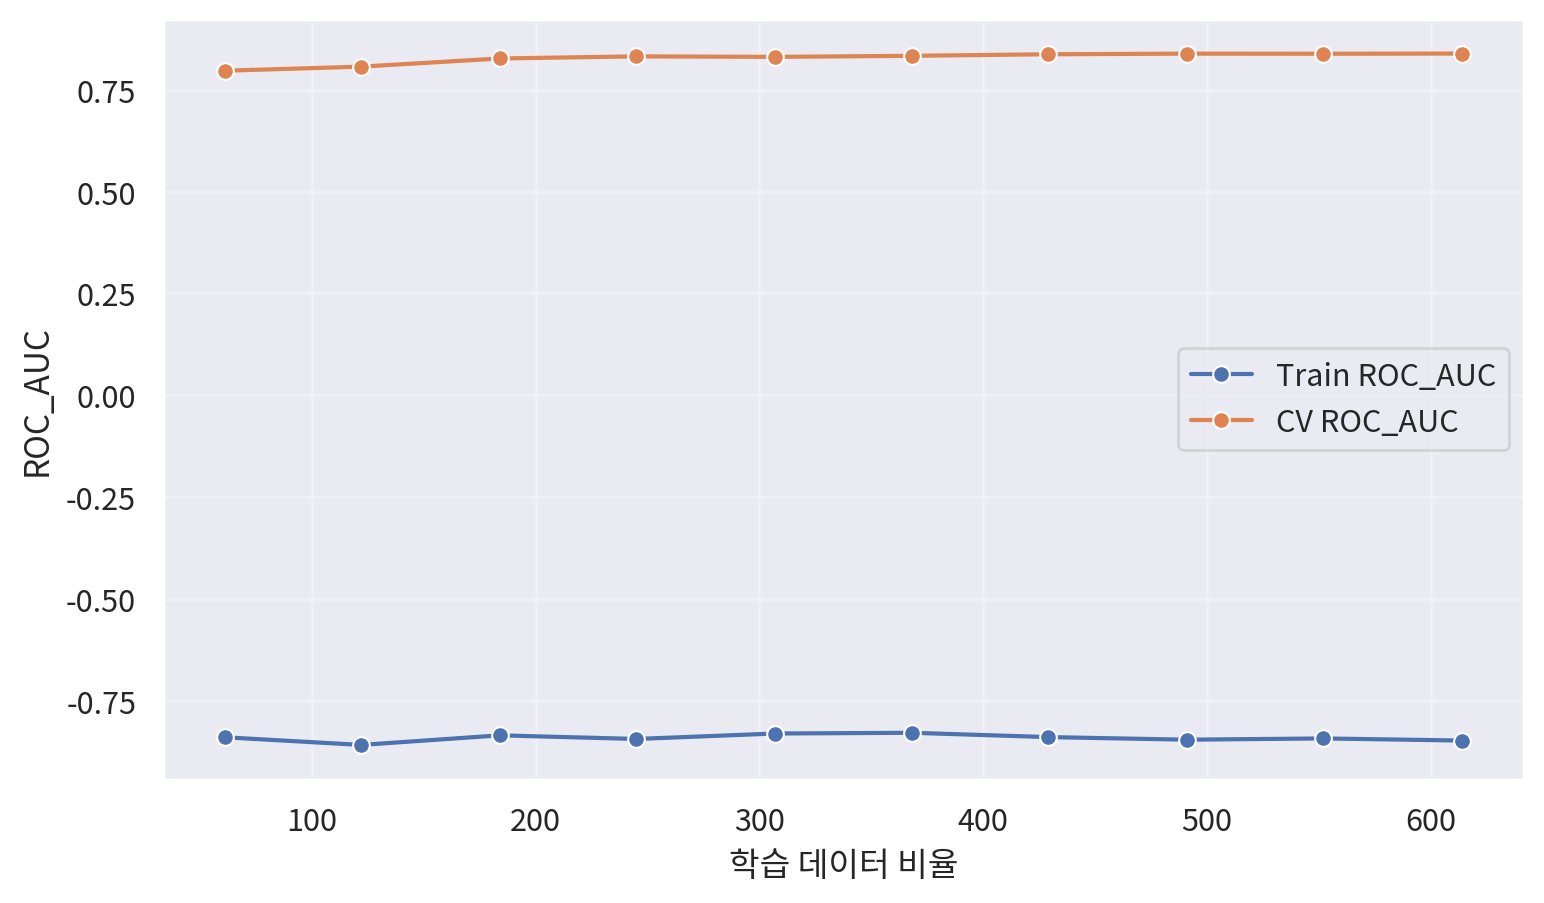

In [51]:
figsize = (1600 / my_dpi, 960 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    markeredgecolor="#ffffff",
    label=f"Train {metric_name}"
)

sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    markeredgecolor="#ffffff",
    label=f"CV {metric_name}"
)

ax.set_xlabel("학습 데이터 비율")
ax.set_ylabel(metric_name)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
